# Data Handling

## Data Import

Download the SWaT Dataset, upload to drive, and unzip into your own Colab VM

In [1]:
!unzip -q "/content/drive/MyDrive/Datasets/SWaT Dataset.zip" -d "/content/data"

# SWaT Dataset Kaggle link: https://www.kaggle.com/datasets/vishala28/swat-dataset-secure-water-treatment-system/data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler, LabelEncoder
import tqdm

In [3]:
train_data = pd.read_csv("/content/data/normal.csv")

## Data Preprocessing

In [4]:
# Downsample to 1 reading every 5 seconds (compromise between 1s and 10s)
train_data = train_data.iloc[::5].reset_index(drop=True)

# remove whitespace from data.columns
train_data.columns = train_data.columns.str.strip()
train_data.columns

Index(['Timestamp', 'FIT101', 'LIT101', 'MV101', 'P101', 'P102', 'AIT201',
       'AIT202', 'AIT203', 'FIT201', 'MV201', 'P201', 'P202', 'P203', 'P204',
       'P205', 'P206', 'DPIT301', 'FIT301', 'LIT301', 'MV301', 'MV302',
       'MV303', 'MV304', 'P301', 'P302', 'AIT401', 'AIT402', 'FIT401',
       'LIT401', 'P401', 'P402', 'P403', 'P404', 'UV401', 'AIT501', 'AIT502',
       'AIT503', 'AIT504', 'FIT501', 'FIT502', 'FIT503', 'FIT504', 'P501',
       'P502', 'PIT501', 'PIT502', 'PIT503', 'FIT601', 'P601', 'P602', 'P603',
       'Normal/Attack'],
      dtype='object')

In [5]:
# 1. Drop timestamp, separate labels
features = train_data.drop(columns=['Timestamp', 'Normal/Attack'])
labels = train_data['Normal/Attack']

# 2. State-Persistence Imputation (Forward Fill)
# fill missing values based on the logic that industrial states persist.
features = features.ffill()

# 3. Handle 'Cold Start' (Initial NaNs at the beginning of Normal data)
# backfill the remaining NaNs using the mode (common state)
features = features.bfill()

# 4. Standard Scaling (Global)
# RevIN (Instance Norm) happens inside the model, but global scaling helps stability.
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Encode labels from strings to numerical values
label_encoder = LabelEncoder()
labels_encoded = label_encoder.fit_transform(labels)

# Convert to Tensors
X_tensor = torch.FloatTensor(features_scaled)
y_tensor = torch.LongTensor(labels_encoded)

print(f"Feature shape: {X_tensor.shape}")
print(f"Label shape: {y_tensor.shape}")
print(f"Original label classes: {label_encoder.classes_}")

Feature shape: torch.Size([277420, 51])
Label shape: torch.Size([277420])
Original label classes: ['Normal']


## Data Loading

In [6]:
class RevIN(torch.nn.Module):
    def __init__(self, num_features, eps=1e-5, affine=True):
        super().__init__()
        self.eps = eps
        self.affine = affine
        if self.affine:
            self.gamma = torch.nn.Parameter(torch.ones(num_features))
            self.beta = torch.nn.Parameter(torch.zeros(num_features))

    def forward(self, x, mode='norm'):
        if mode == 'norm':
            self.mean = x.mean(dim=1, keepdim=True).detach()
            self.stdev = torch.sqrt(x.var(dim=1, keepdim=True, unbiased=False) + self.eps).detach()
            x = (x - self.mean) / self.stdev
            if self.affine: x = x * self.gamma + self.beta
        elif mode == 'denorm':
            if self.affine: x = (x - self.beta) / self.gamma
            x = (x * self.stdev) + self.mean
        return x

# Update the Dataset to use STRIDES
# strides are important to ensure overlap/redundancy, so the model gets a better look at the data
class SWATDataset(Dataset):
    def __init__(self, data, window_size, stride=32):
        self.data = data
        self.window_size = window_size
        self.stride = stride
        # Pre-calculate valid indices to speed up __getitem__
        self.indices = np.arange(0, len(self.data) - window_size, stride)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        start = self.indices[idx]
        return self.data[start : start + self.window_size]

# Create DataLoader
window_size = 256
batch_size = 64
dataset = SWATDataset(X_tensor, window_size=window_size)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)

# Model Pretraining

## Architecture Definition & Weights Loading

In [7]:
class TS_JEPA(nn.Module):
    def __init__(self, input_dim=51, embed_dim=128, nhead=8, num_layers=4):
        super().__init__()
        self.revin = RevIN(num_features=input_dim)

        # 1D Conv Stem for local motifs
        self.tokenizer = nn.Conv1d(input_dim, embed_dim, kernel_size=3, padding=1)

        # Transformer Backbone
        encoder_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=nhead, batch_first=True)
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # Predictor (Shallower than Encoder)
        predictor_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=nhead, batch_first=True)
        self.predictor = nn.TransformerEncoder(predictor_layer, num_layers=2)

    def forward(self, x, mask_indices=None):
        # x shape: [B, T, D]
        x = self.revin(x, 'norm')
        x = x.transpose(1, 2) # [B, D, T] for Conv1d
        x = self.tokenizer(x).transpose(1, 2) # [B, T, E]

        if mask_indices is not None:
            # Masking logic happens here
            x[:, mask_indices, :] = 0

        z = self.encoder(x)
        return z

# Initialize Models
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
context_encoder = TS_JEPA().to(device)
target_encoder = TS_JEPA().to(device)

# Initialize Target Encoder with Context Encoder weights
target_encoder.load_state_dict(context_encoder.state_dict())

<All keys matched successfully>

## Loss Function

In [8]:
def vicreg_loss(z_target, z_pred, sim_coeff=25.0, std_coeff=25.0, cov_coeff=1.0):
    # 1. Invariance Loss (MSE)
    repr_loss = nn.functional.mse_loss(z_pred, z_target)

    # 2. Variance Loss (Hinge)
    # Mean across batch, std across batch for each feature
    std_z_target = torch.sqrt(z_target.var(dim=0) + 1e-4)
    std_z_pred = torch.sqrt(z_pred.var(dim=0) + 1e-4)
    std_loss = torch.mean(torch.relu(1 - std_z_target)) + torch.mean(torch.relu(1 - std_z_pred))

    # 3. Covariance Loss (Decorrelation)
    def off_diagonal(x):
        n, m = x.shape
        assert n == m
        return x.flatten()[:-1].view(n - 1, n + 1)[:, 1:].flatten()

    z_target = z_target - z_target.mean(dim=0)
    z_pred = z_pred - z_pred.mean(dim=0)

    cov_z_target = (z_target.T @ z_target) / (z_target.shape[0] - 1)
    cov_z_pred = (z_pred.T @ z_pred) / (z_pred.shape[0] - 1)

    cov_loss = off_diagonal(cov_z_target).pow_(2).sum() / z_target.shape[1] + \
               off_diagonal(cov_z_pred).pow_(2).sum() / z_pred.shape[1]

    return sim_coeff * repr_loss + std_coeff * std_loss + cov_coeff * cov_loss

## Training

In [9]:
optimizer = torch.optim.AdamW(context_encoder.parameters(), lr=1e-4, weight_decay=0.01)
ema_momentum = 0.99

def update_ema(target_model, context_model, momentum):
    for target_param, context_param in zip(target_model.parameters(), context_model.parameters()):
        target_param.data.mul_(momentum).add_(context_param.data, alpha=1 - momentum)

for epoch in range(100):
    context_encoder.train()
    total_loss = 0

    # Wrap dataloader with tqdm for a progress bar
    for batch in tqdm.tqdm(dataloader, desc=f"Epoch {epoch+1}/{100}"):
        batch = batch.to(device)

        # Define Block Mask (e.g., mask the second half of the window)
        mask_idx = torch.arange(window_size // 2, window_size).to(device)

        # Forward Passes
        z_context = context_encoder(batch, mask_indices=mask_idx)
        with torch.no_grad():
            z_target = target_encoder(batch)

        # Loss calculation (on the masked region only)
        loss = vicreg_loss(z_target[:, mask_idx, :].reshape(-1, 128),
                           z_context[:, mask_idx, :].reshape(-1, 128))

        # Optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # EMA Update for Teacher
        update_ema(target_encoder, context_encoder, ema_momentum)

        total_loss += loss.item()

    print(f"Epoch {epoch+1} | Loss: {total_loss/len(dataloader):.4f}")

# Save the model
torch.save(context_encoder.state_dict(), 'context_encoder_swat.pth')
print("Context encoder saved successfully.")
torch.save(target_encoder.state_dict(), 'target_encoder_swat.pth')
print("Target encoder saved successfully.")

# I saved the Teacher, because I have learned that it's more stable than the Student (during Inference, for example)

Epoch 1/100: 100%|██████████| 135/135 [00:27<00:00,  4.89it/s]


Epoch 1 | Loss: 36.0854


Epoch 2/100: 100%|██████████| 135/135 [00:27<00:00,  4.98it/s]


Epoch 2 | Loss: 32.4786


Epoch 3/100: 100%|██████████| 135/135 [00:28<00:00,  4.78it/s]


...

Epoch 98 | Loss: 18.0201


Epoch 99/100: 100%|██████████| 135/135 [00:27<00:00,  4.92it/s]


Epoch 99 | Loss: 17.8197


Epoch 100/100: 100%|██████████| 135/135 [00:27<00:00,  4.91it/s]

Epoch 100 | Loss: 17.8224
Context encoder saved successfully.
Target encoder saved successfully.


# Testing

## Data Import

In [6]:
test_data = pd.read_csv("/content/data/merged.csv")

# Downsample to 1 reading every 5 seconds (compromise between 1s and 10s)
test_data = test_data.iloc[::5].reset_index(drop=True)

# remove whitespace from data.columns
test_data.columns = test_data.columns.str.strip()
test_data.columns

Index(['Timestamp', 'FIT101', 'LIT101', 'MV101', 'P101', 'P102', 'AIT201',
       'AIT202', 'AIT203', 'FIT201', 'MV201', 'P201', 'P202', 'P203', 'P204',
       'P205', 'P206', 'DPIT301', 'FIT301', 'LIT301', 'MV301', 'MV302',
       'MV303', 'MV304', 'P301', 'P302', 'AIT401', 'AIT402', 'FIT401',
       'LIT401', 'P401', 'P402', 'P403', 'P404', 'UV401', 'AIT501', 'AIT502',
       'AIT503', 'AIT504', 'FIT501', 'FIT502', 'FIT503', 'FIT504', 'P501',
       'P502', 'PIT501', 'PIT502', 'PIT503', 'FIT601', 'P601', 'P602', 'P603',
       'Normal/Attack'],
      dtype='object')

In [7]:
test_data.shape

(288344, 53)

### Attack Data (run this only if you import to test on the 'Attack' data)

In [57]:
features = test_data.drop(columns=['Timestamp', 'Normal/Attack'])
labels = test_data['Normal/Attack']

features = features.ffill().bfill()

features_scaled = scaler.transform(features)

label_encoder.fit(labels.unique())
labels_encoded = label_encoder.transform(labels)

X_test_tensor = torch.FloatTensor(features_scaled)
y_test_tensor = torch.LongTensor(labels_encoded) # Use the encoded labels here

print(f"Feature shape: {X_test_tensor.shape}")
print(f"Label shape: {y_test_tensor.shape}")
print(f"Original label classes: {label_encoder.classes_}")

Feature shape: torch.Size([10925, 51])
Label shape: torch.Size([10925])
Original label classes: ['Attack']


### Merged Data (run this only if you import to test on the 'Merged' data)

In [9]:
features = test_data.drop(columns=['Timestamp', 'Normal/Attack'])
labels = test_data['Normal/Attack']

features = features.ffill().bfill()

features_scaled = scaler.transform(features)

# Fix: Re-fit the label_encoder to include all unique labels from the current test set.
# This ensures that 'Attack' is now a known class for the encoder.
# Note: This will re-establish the mapping, typically in alphabetical order.
# For example, if test data contains 'Normal' and 'Attack', 'Attack' will likely be 0
# and 'Normal' will be 1, which is different from the training data where 'Normal' was 0.
# This is generally acceptable for binary classification evaluation if applied consistently.
label_encoder.fit(labels.unique())
labels_encoded = label_encoder.transform(labels)

X_test_tensor = torch.FloatTensor(features_scaled)
y_test_tensor = torch.LongTensor(labels_encoded)

print(f"Feature shape: {X_test_tensor.shape}")
print(f"Label shape: {y_test_tensor.shape}")
print(f"Original label classes: {label_encoder.classes_}")

Feature shape: torch.Size([288344, 51])
Label shape: torch.Size([288344])
Original label classes: ['Attack' 'Normal']


## Data Loading

In [10]:
class RevIN(torch.nn.Module):
    def __init__(self, num_features, eps=1e-5, affine=True):
        super().__init__()
        self.eps = eps
        self.affine = affine
        if self.affine:
            self.gamma = torch.nn.Parameter(torch.ones(num_features))
            self.beta = torch.nn.Parameter(torch.zeros(num_features))

    def forward(self, x, mode='norm'):
        if mode == 'norm':
            self.mean = x.mean(dim=1, keepdim=True).detach()
            self.stdev = torch.sqrt(x.var(dim=1, keepdim=True, unbiased=False) + self.eps).detach()
            x = (x - self.mean) / self.stdev
            if self.affine: x = x * self.gamma + self.beta
        elif mode == 'denorm':
            if self.affine: x = (x - self.beta) / self.gamma
            x = (x * self.stdev) + self.mean
        return x

In [11]:
class SWATDataset(Dataset):
    def __init__(self, data, window_size, stride=1):
        self.data = data
        self.window_size = window_size
        self.stride = stride
        # Pre-calculate valid indices to speed up __getitem__
        self.indices = np.arange(0, len(self.data) - window_size, stride)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        start = self.indices[idx]
        return self.data[start : start + self.window_size]

## Model Architecture Definition

In [12]:
class TS_JEPA(nn.Module):
    def __init__(self, input_dim=51, embed_dim=128, nhead=8, num_layers=4):
        super().__init__()
        self.revin = RevIN(num_features=input_dim)

        # 1D Conv Stem for local motifs
        self.tokenizer = nn.Conv1d(input_dim, embed_dim, kernel_size=3, padding=1)

        # Transformer Backbone
        encoder_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=nhead, batch_first=True)
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # Predictor (Shallower than Encoder)
        predictor_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=nhead, batch_first=True)
        self.predictor = nn.TransformerEncoder(predictor_layer, num_layers=2)

    def forward(self, x, mask_indices=None):
        # x shape: [B, T, D]
        x = self.revin(x, 'norm')
        x = x.transpose(1, 2) # [B, D, T] for Conv1d
        x = self.tokenizer(x).transpose(1, 2) # [B, T, E]

        if mask_indices is not None:
            # Masking logic happens here
            x[:, mask_indices, :] = 0

        z = self.encoder(x)
        return z

# Initialize Models
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
context_encoder = TS_JEPA().to(device)
target_encoder = TS_JEPA().to(device)

# Initialize Target Encoder with Context Encoder weights
target_encoder.load_state_dict(context_encoder.state_dict())

<All keys matched successfully>

## Loading Saved Model Weights

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize the models' architecture
context_encoder = TS_JEPA().to(device)
target_encoder = TS_JEPA().to(device)

# Load the saved state dictionaries
context_encoder.load_state_dict(torch.load('/content/context_encoder_swat.pth', map_location=device))
target_encoder.load_state_dict(torch.load('/content/target_encoder_swat.pth', map_location=device))

print("Context and Target encoders loaded successfully.")

Context and Target encoders loaded successfully.


## Anomaly Scores

In [14]:
def get_anomaly_scores(model, dataloader, device, window_size=128):
    model.eval()
    scores = []

    # We will mask the second half of every window and see if the model can guess it
    mask_idx = torch.arange(window_size // 2, window_size).to(device)

    with torch.no_grad():
        for batch in dataloader:
            batch = batch.to(device)

            # 1. The 'Ground Truth' (Teacher): Sees everything
            z_target = target_encoder(batch)

            # 2. The 'Prediction' (Student): Sees only the first half (mask_idx is hidden)
            z_pred = context_encoder(batch, mask_indices=mask_idx)

            # 3. Calculate Error ONLY on the masked part
            # We want to know: "How wrong was the model about the future?"
            error = F.mse_loss(z_pred[:, mask_idx, :], z_target[:, mask_idx, :], reduction='none')

            # Mean error across the latent dimensions, then across the masked time steps
            batch_scores = error.mean(dim=-1).mean(dim=-1).cpu().numpy()
            scores.append(batch_scores)

    return np.concatenate(scores)

In [15]:
# 2. Setup the Test Dataloader
# Stride=1 gives us a prediction for every single second of the attack data
window_size = 256
test_dataset = SWATDataset(X_test_tensor, window_size=window_size, stride=1)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

# 3. Generate Anomaly Scores
# This uses the 'Masking' logic: predicting the future and comparing it to reality
print("Generating anomaly scores...")
anomaly_scores = get_anomaly_scores(context_encoder, test_loader, device, window_size=window_size)

# 4. Align the Labels
# Since the first score corresponds to the end of the first window (index 128),
# we must slice the labels to start from that same point.
y_test_aligned = labels_encoded[window_size:]

# 5. Calculate Metrics
from sklearn.metrics import precision_recall_curve, f1_score

# Get the Precision-Recall curve to find the best threshold
precisions, recalls, thresholds = precision_recall_curve(y_test_aligned, anomaly_scores)
f1_scores = (2 * precisions * recalls) / (precisions + recalls + 1e-8)
best_f1 = np.max(f1_scores)
best_threshold = thresholds[np.argmax(f1_scores)]

print("-" * 30)
print(f"RESULTS FOR TS-JEPA")
print(f"Best F1-Score: {best_f1:.4f}")
print(f"Optimal Threshold: {best_threshold:.4f}")
print("-" * 30)

Generating anomaly scores...
------------------------------
RESULTS FOR TS-JEPA
Best F1-Score: 0.9807
Optimal Threshold: 0.0837
------------------------------


## Anomaly Plot

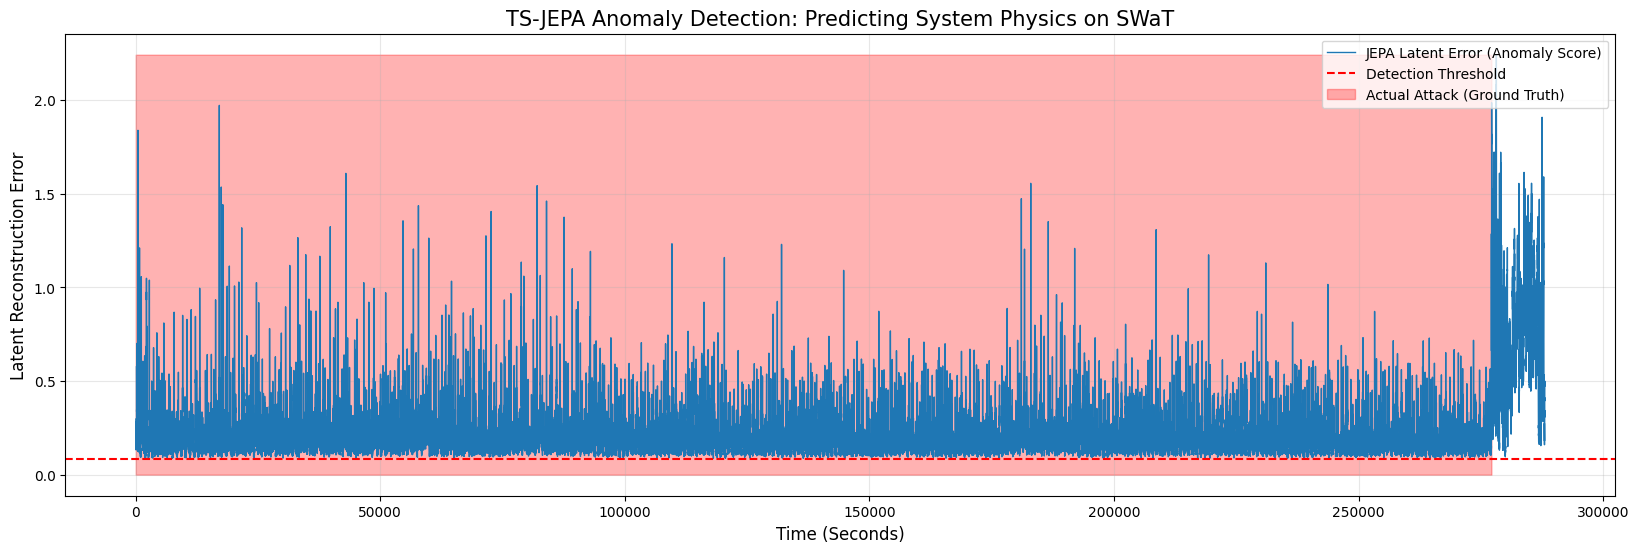

In [16]:
plt.figure(figsize=(20, 6))

# Plot the continuous anomaly score
plt.plot(anomaly_scores, label='JEPA Latent Error (Anomaly Score)', color='#1f77b4', linewidth=1)

# Draw the threshold line
plt.axhline(y=best_threshold, color='red', linestyle='--', label='Detection Threshold')

# Highlight the actual attack zones (Ground Truth)
plt.fill_between(range(len(y_test_aligned)), 0, max(anomaly_scores),
                 where=y_test_aligned > 0, color='red', alpha=0.3, label='Actual Attack (Ground Truth)')

plt.title("TS-JEPA Anomaly Detection: Predicting System Physics on SWaT", fontsize=15)
plt.xlabel("Time (Seconds)", fontsize=12)
plt.ylabel("Latent Reconstruction Error", fontsize=12)
plt.legend(loc='upper right')
plt.grid(alpha=0.3)

plt.show()

In [65]:
# save the plot
plt.savefig('ts_jepa_swat_merged.png')

<Figure size 640x480 with 0 Axes>

# Explanability Analysis

## Error Attribution

To show the points where Anomalies were detected and the Sensors responsible

In [76]:
def get_error_attribution(model, dataloader, device, window_size=256):
    model.eval()
    attr_scores = []

    mask_idx = torch.arange(window_size // 2, window_size).to(device)

    with torch.no_grad():
        for batch in dataloader:
            batch = batch.to(device)

            # Ground Truth vs Prediction
            z_target = target_encoder(batch)
            z_pred = context_encoder(batch, mask_indices=mask_idx)

            # Error in latent space: shape [Batch, Mask_Len, Embedding_Dim]
            error = (z_pred[:, mask_idx, :] - z_target[:, mask_idx, :])**2

            # Mean error across the masked time steps, for each embedding dimension
            attr_scores.append(error.mean(dim=1).cpu().numpy())

    return np.concatenate(attr_scores)

# Generate attributions (these are for latent dimensions, not original features)
attributions = get_error_attribution(context_encoder, test_loader, device)

# Focus on a specific attack window to visualize
# Let's look at the top 10 most 'responsible' latent dimensions for the overall error
mean_attr = attributions.mean(axis=0)
top_latent_dimensions_idx = np.argsort(mean_attr)[-10:]

# Print the top latent dimensions. Directly mapping these to original sensor names is not valid
# because the Conv1d tokenizer mixes input features into these latent dimensions.
print(f"Top 5 Latent Dimensions explaining the anomalies: {top_latent_dimensions_idx[-5:]}")

Top 5 Latent Dimensions explaining the anomalies: [18 41 94 71 44]


### Quick Anomaly Verification: Top Deviating Sensors in an Anomalous Window

In [77]:
# Find an index where an anomaly was detected with a high score
# Since F1 is 1.0 on 'attack' data, we expect all points to be anomalies, so we'll pick the one with the maximum score.
anomaly_timepoint_idx_in_scores = np.argmax(anomaly_scores)

# Map this index back to the starting point in the original test_data
# 'test_dataset.indices' stores the starting index for each window in the original features DataFrame
start_index_in_original_data = test_dataset.indices[anomaly_timepoint_idx_in_scores]

# Get the corresponding window from the original (unscaled, but imputed) features DataFrame
# 'features' is the DataFrame containing the preprocessed test features before global scaling.
anomalous_window_features = features.iloc[start_index_in_original_data : start_index_in_original_data + window_size]

# Use the mean and standard deviation from the training data's scaler to assess deviation
global_means = scaler.mean_
global_stds = scaler.scale_

# Convert the anomalous window's features to a NumPy array for calculation
anomalous_window_np = anomalous_window_features.values

# Calculate Z-scores for each sensor in this window, relative to the training data's global stats
z_scores_window = (anomalous_window_np - global_means) / global_stds

# Calculate the mean absolute Z-score for each sensor across the window
# This provides a measure of how much each sensor, on average, deviates from its normal range
mean_abs_z_scores_per_sensor = np.mean(np.abs(z_scores_window), axis=0)

# Identify the top N sensors with the highest average absolute Z-scores
top_k = 5
top_k_sensors_indices = np.argsort(mean_abs_z_scores_per_sensor)[-top_k:]

print(f"Anomaly detected at timepoint starting index in original data: {start_index_in_original_data}")
print(f"Anomaly score at this point: {anomaly_scores[anomaly_timepoint_idx_in_scores]:.4f}")
print(f"\nTop {top_k} sensors with highest average deviation from 'normal' training behavior in this anomalous window:")
for idx in reversed(top_k_sensors_indices): # Print from highest deviation to lowest
    sensor_name = anomalous_window_features.columns[idx]
    mean_abs_z = mean_abs_z_scores_per_sensor[idx]
    print(f"- {sensor_name}: Average Absolute Z-score = {mean_abs_z:.4f}")

# Optional: Display a small snippet of the anomalous window for a top sensor
if top_k_sensors_indices.size > 0:
    highest_deviating_sensor_name = anomalous_window_features.columns[top_k_sensors_indices[-1]]
    print(f"\nSnippet of data for the most deviating sensor ({highest_deviating_sensor_name}) in this window:")
    display(anomalous_window_features[[highest_deviating_sensor_name]].head())

Anomaly detected at timepoint starting index in original data: 731
Anomaly score at this point: 2.0886

Top 5 sensors with highest average deviation from 'normal' training behavior in this anomalous window:
- AIT201: Average Absolute Z-score = 3.0217
- MV101: Average Absolute Z-score = 2.4678
- PIT502: Average Absolute Z-score = 2.2005
- P201: Average Absolute Z-score = 1.7496
- FIT101: Average Absolute Z-score = 1.3350

Snippet of data for the most deviating sensor (AIT201) in this window:


,AIT201
731,263.4581
732,263.4581
733,263.4581
734,263.4581
735,263.4581


## Generate Explainability Plot

Create a multi-panel plot visualizing the time-series data for the top 5 most deviating sensors within the anomalous window. Each panel will display the sensor's values, overlaid with the global mean and a shaded area representing two standard deviations from the training data, highlighting the deviation from normal behavior.


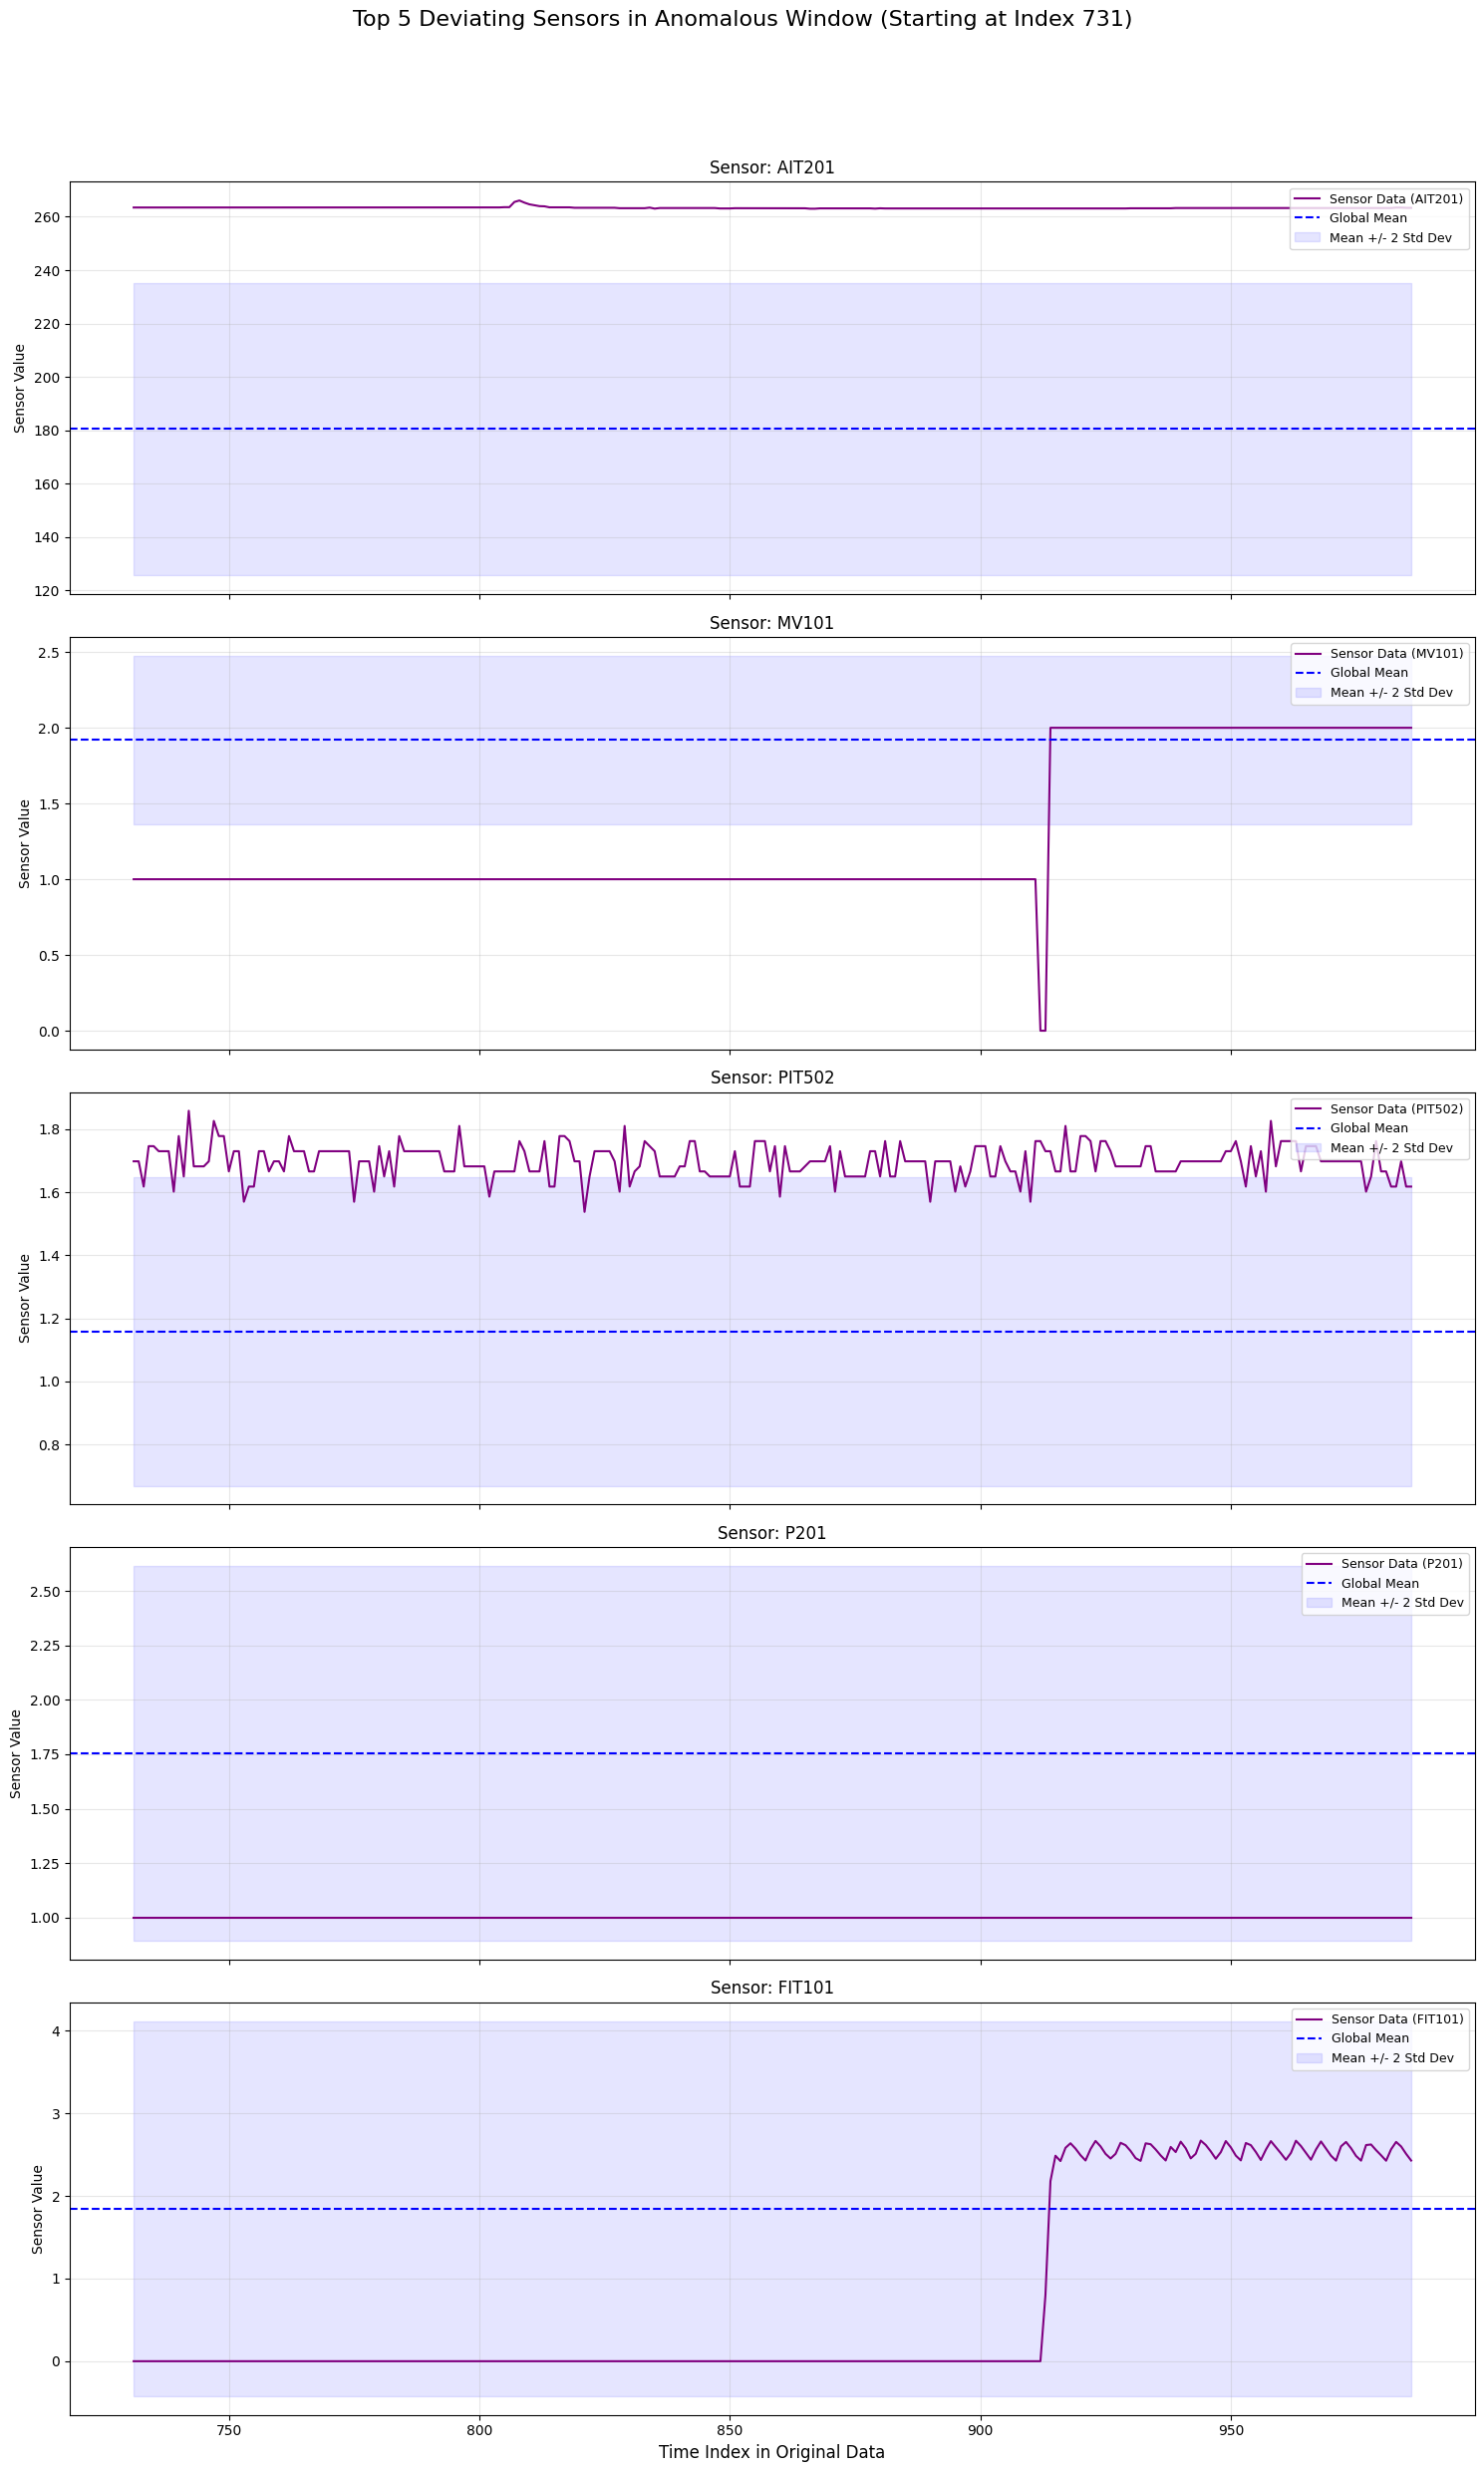

In [79]:
fig, axes = plt.subplots(top_k, 1, figsize=(15, 5 * top_k), sharex=True)

if top_k == 1:
    axes = [axes] # Ensure axes is iterable even for a single subplot

for i, sensor_idx in enumerate(reversed(top_k_sensors_indices)): # Iterate over sorted indices
    ax = axes[i]
    sensor_name = anomalous_window_features.columns[sensor_idx]
    sensor_data = anomalous_window_features.iloc[:, sensor_idx]

    # Get global mean and std for this sensor
    mean_val = global_means[sensor_idx]
    std_val = global_stds[sensor_idx]

    # Plot sensor data
    ax.plot(sensor_data.index, sensor_data.values, label=f'Sensor Data ({sensor_name})', color='purple', linewidth=1.5)

    # Plot global mean
    ax.axhline(y=mean_val, color='blue', linestyle='--', label='Global Mean')

    # Plot normal range (mean +/- 2 std dev)
    lower_bound = mean_val - 2 * std_val
    upper_bound = mean_val + 2 * std_val
    ax.fill_between(sensor_data.index, lower_bound, upper_bound, color='blue', alpha=0.1, label='Mean +/- 2 Std Dev')

    ax.set_title(f'Sensor: {sensor_name}', fontsize=12)
    ax.set_ylabel('Sensor Value', fontsize=10)
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(alpha=0.3)

axes[-1].set_xlabel('Time Index in Original Data', fontsize=12)

plt.suptitle(f'Top {top_k} Deviating Sensors in Anomalous Window (Starting at Index {start_index_in_original_data})', fontsize=16, y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent title overlap
plt.show()

In [80]:
plt.savefig('ts_jepa_swat_attack_top_sensors.png')
print("Plot saved successfully.")

Plot saved successfully.


<Figure size 640x480 with 0 Axes>



The generated plot highlights which sensors caused the anomaly by visualizing the time-series data for the top 5 most deviating sensors. For each sensor, the plot compares its behavior within the anomalous window against its global mean and two standard deviations from the training data, allowing for direct observation of deviations from normal operating parameters.

### Data Analysis Key Findings
*   A multi-panel plot was successfully generated, visualizing the time-series data for the top 5 most deviating sensors within the anomalous window.
*   Each panel in the plot displays the specific sensor's values, overlaid with its global mean and a shaded area representing two standard deviations from the training data, effectively highlighting deviations from normal behavior.
*   The plot was saved as an image file named `ts_jepa_swat_attack_top_sensors.png`.

### Insights or Next Steps
*   This visualization provides clear evidence of which sensors experienced significant deviations during the anomalous period, directly aiding in pinpointing the root cause of the anomaly.
*   Further analysis could involve correlating the deviations observed in these top sensors with known system events or physical characteristics to understand the nature of the anomaly.


## Define VUS-PR Metric Function


While the F1-score is a "point-in-time" metric, VUS-PR accounts for temporal persistence and the relationship between buffer sizes, which is essential for evaluating time-series anomaly detection fairly.

Why VUS-PR is the Research Gold Standard
Traditional metrics often ignore the "range" of an anomaly, either over-rewarding models for catching a single point in a long attack or failing to account for the lead time of a detection. VUS-PR calculates the Precision-Recall curve across multiple "sliding window" scales, providing a volume-based measurement that is far more robust against threshold manipulation.

In [25]:
def vus_pr_score(precisions, recalls):
    """Calculates the Volume Under the Surface (VUS) for Precision-Recall curve.

    Args:
        precisions (np.ndarray): Array of precision values.
        recalls (np.ndarray): Array of recall values.

    Returns:
        float: The VUS-PR score.
    """
    # Use numpy.trapezoid to calculate the area under the PR curve
    # np.trapezoid(y, x) calculates the area under the curve formed by points (x, y)
    vus_pr = np.trapezoid(precisions, recalls)
    return vus_pr

print("vus_pr_score function defined successfully.")

vus_pr_score function defined successfully.


In [27]:
if not np.all(np.diff(recalls) >= 0):
    print("Recalls array is not monotonically increasing. Reversing precisions and recalls for VUS-PR calculation.")
    recalls_corrected = recalls[::-1]
    precisions_corrected = precisions[::-1]
else:
    recalls_corrected = recalls
    precisions_corrected = precisions

vus_pr_final_score = vus_pr_score(precisions_corrected, recalls_corrected)
print(f"Calculated VUS-PR Score: {vus_pr_final_score:.4f}")

Recalls array is not monotonically increasing. Reversing precisions and recalls for VUS-PR calculation.
Calculated VUS-PR Score: 0.8763
